In [99]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [100]:
df = pd.read_csv("processed_dataset.csv")

df.head()

,cat__alert_green,cat__alert_orange,cat__alert_red,cat__alert_yellow,cat__net_ak,cat__net_at,cat__net_ci,cat__net_duputel,cat__net_hv,cat__net_nc,...,num__longitude,num__Year,num__Month,num__Day,num__Hour,num__Energy_Index,num__Tsunami_Flag,num__High_Alert,num__Years_Ago,Damage_Level
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.985112,1.582253,0.40483,0.083822,0.013187,-0.106398,-0.693889,-0.196014,-1.582253,0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.189010,1.582253,0.11792,0.438001,-1.725784,-0.106398,-0.693889,-0.196014,-1.582253,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.037814,1.582253,0.11792,0.201882,-1.291041,-0.105297,-0.693889,-0.196014,-1.582253,0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.807072,1.582253,0.11792,0.083822,-0.856298,-0.079118,1.441153,-0.196014,-1.582253,3
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.807898,1.582253,0.11792,0.083822,-0.856298,-0.066762,1.441153,-0.196014,-1.582253,2


In [101]:
X = df.drop("Damage_Level",axis=1)

y = df["Damage_Level"]

In [102]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.20,

random_state=42,

stratify=y

)

In [103]:
print(X_train.shape)
print(X_test.shape)

(800, 110)
(200, 110)


In [104]:
models={

"Logistic Regression":LogisticRegression(),

"Decision Tree":DecisionTreeClassifier(),

"Random Forest":RandomForestClassifier(),

"KNN":KNeighborsClassifier(),

"SVM":SVC(),

"Naive Bayes":GaussianNB(),

"Gradient Boosting":GradientBoostingClassifier(),

"AdaBoost":AdaBoostClassifier(),

"Extra Trees":ExtraTreesClassifier()

}

In [105]:
results=[]

In [106]:
for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,pred)

    precision=precision_score(
        y_test,
        pred,
        average="weighted"
    )

    recall=recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1=f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])

In [107]:
results=pd.DataFrame(

results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1 Score"

]

)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.930,0.931021,0.930,0.929628
1,Decision Tree,0.910,0.909925,0.910,0.909433
2,Random Forest,0.865,0.865366,0.865,0.863767
3,KNN,0.675,0.688734,0.675,0.671573
4,SVM,0.915,0.917917,0.915,0.914195
5,Naive Bayes,0.380,0.557696,0.380,0.342500
6,Gradient Boosting,0.950,0.950464,0.950,0.949993
7,AdaBoost,0.785,0.834003,0.785,0.780635
8,Extra Trees,0.830,0.830420,0.830,0.829412


In [108]:
results.sort_values(

"Accuracy",

ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score
6,Gradient Boosting,0.950,0.950464,0.950,0.949993
0,Logistic Regression,0.930,0.931021,0.930,0.929628
4,SVM,0.915,0.917917,0.915,0.914195
1,Decision Tree,0.910,0.909925,0.910,0.909433
2,Random Forest,0.865,0.865366,0.865,0.863767
8,Extra Trees,0.830,0.830420,0.830,0.829412
7,AdaBoost,0.785,0.834003,0.785,0.780635
3,KNN,0.675,0.688734,0.675,0.671573
5,Naive Bayes,0.380,0.557696,0.380,0.342500


In [109]:
best_model_name=results.sort_values(

"Accuracy",

ascending=False

).iloc[0]["Model"]

best_model_name

'Gradient Boosting'

In [110]:
best_model=models[best_model_name]


best_model.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [111]:
prediction=best_model.predict(X_test)

In [112]:
print(classification_report(

y_test,

prediction

))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        50
           1       0.98      0.96      0.97        51
           2       0.94      0.98      0.96        49
           3       0.96      0.92      0.94        50

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [113]:
cm=confusion_matrix(

y_test,

prediction

)

cm

array([[47,  0,  1,  2],
       [ 0, 49,  2,  0],
       [ 0,  1, 48,  0],
       [ 4,  0,  0, 46]])

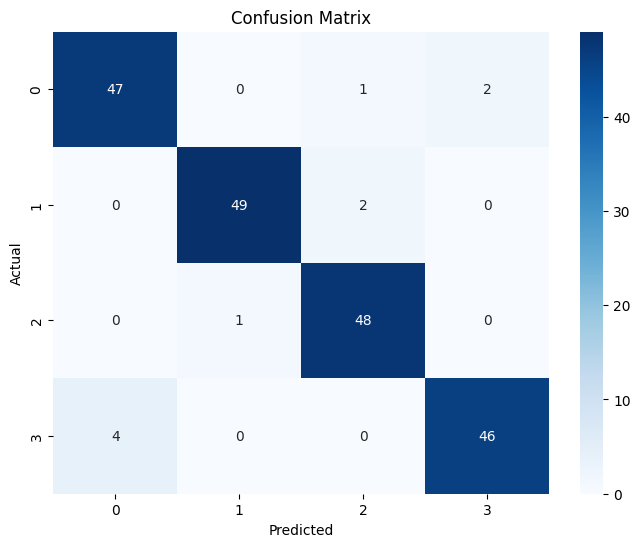

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(

cm,

annot=True,

fmt="d",

cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

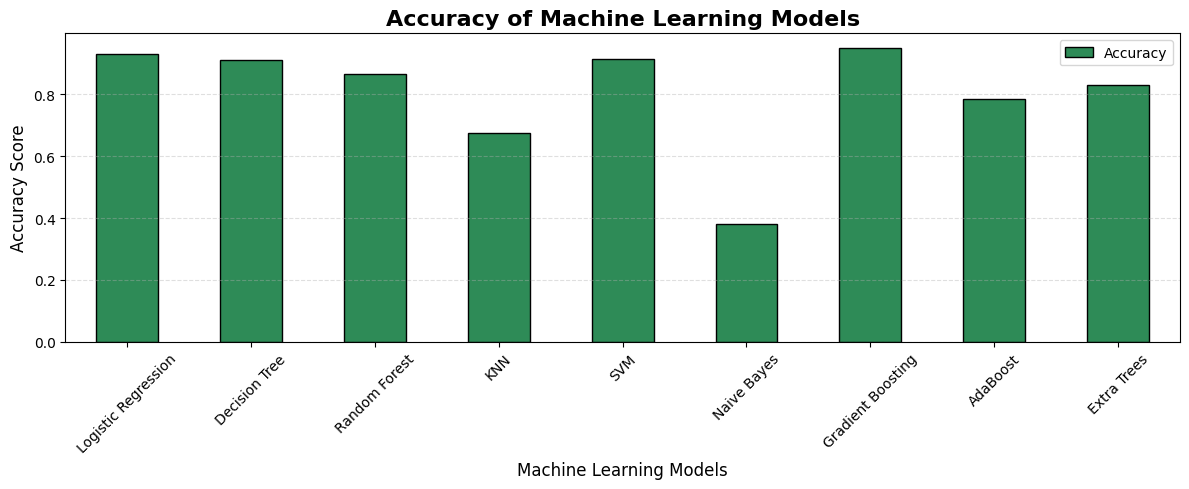

In [115]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(12,5),
    rot=45,
    color="#2E8B57",   # Professional green
    edgecolor="black"
)

plt.title("Accuracy of Machine Learning Models", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

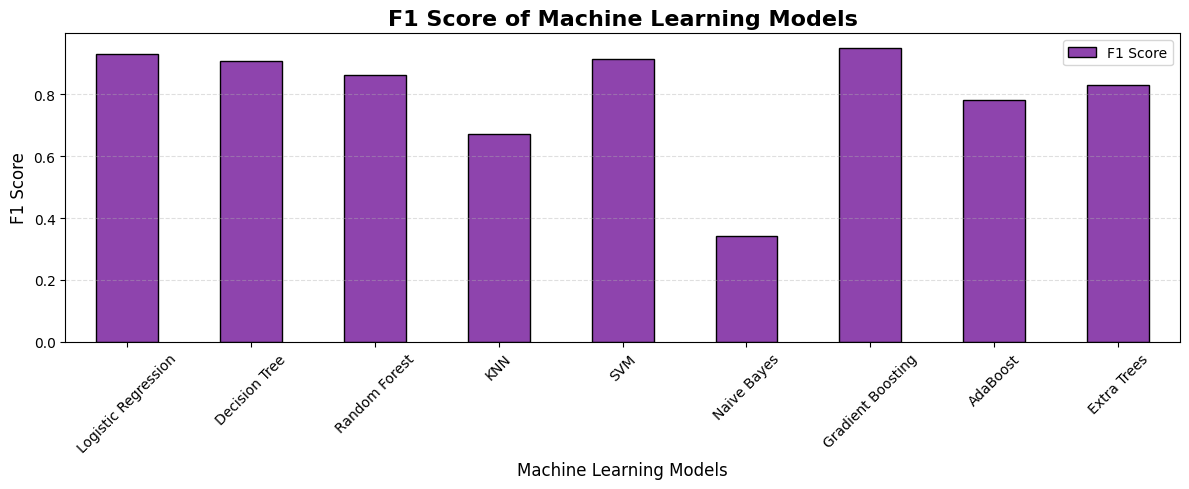

In [116]:
results.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    figsize=(12,5),
    rot=45,
    color="#8E44AD",   # Purple
    edgecolor="black"
)

plt.title("F1 Score of Machine Learning Models", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

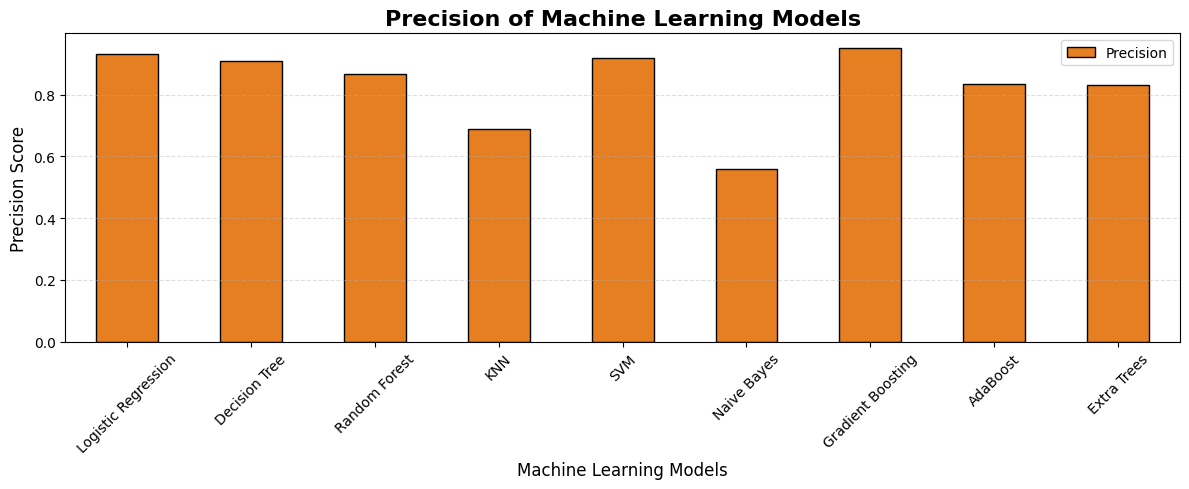

In [117]:
results.plot(
    x="Model",
    y="Precision",
    kind="bar",
    figsize=(12,5),
    rot=45,
    color="#E67E22",   # Orange
    edgecolor="black"
)

plt.title("Precision of Machine Learning Models", fontsize=16, fontweight="bold")
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Precision Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

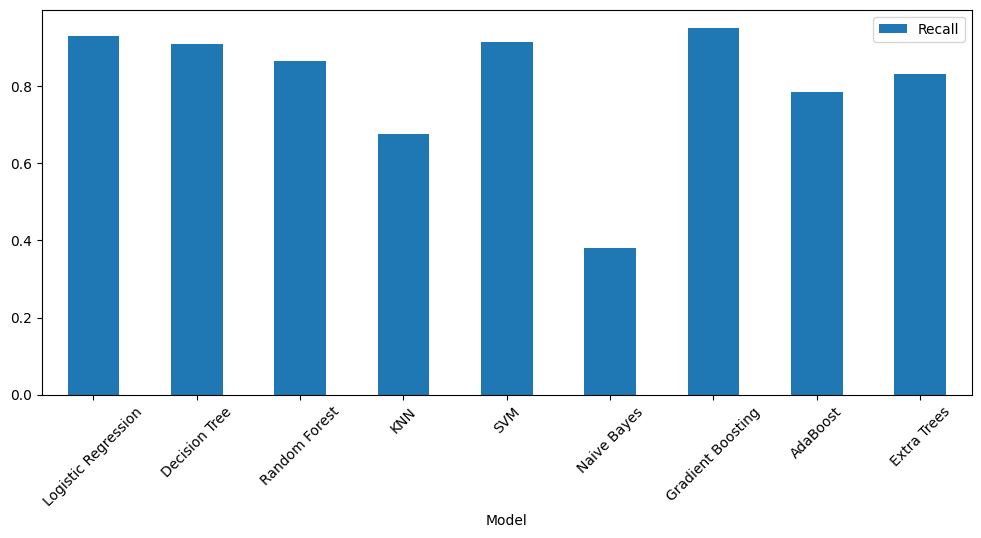

In [118]:
results.plot(

x="Model",

y="Recall",

kind="bar",

figsize=(12,5),

rot=45

)

plt.show()

In [119]:
best_model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [120]:
pickle.dump(

best_model,

open("model.pkl","wb")

)

print("Model Saved Successfully")

Model Saved Successfully


In [121]:
importances=None

if hasattr(best_model,"feature_importances_"):

    importances=best_model.feature_importances_

    feature_names=X.columns

    feature_df=pd.DataFrame({

        "Feature":feature_names,

        "Importance":importances

    })

    feature_df=feature_df.sort_values(

        "Importance",

        ascending=False

    )

    feature_df.head(20)

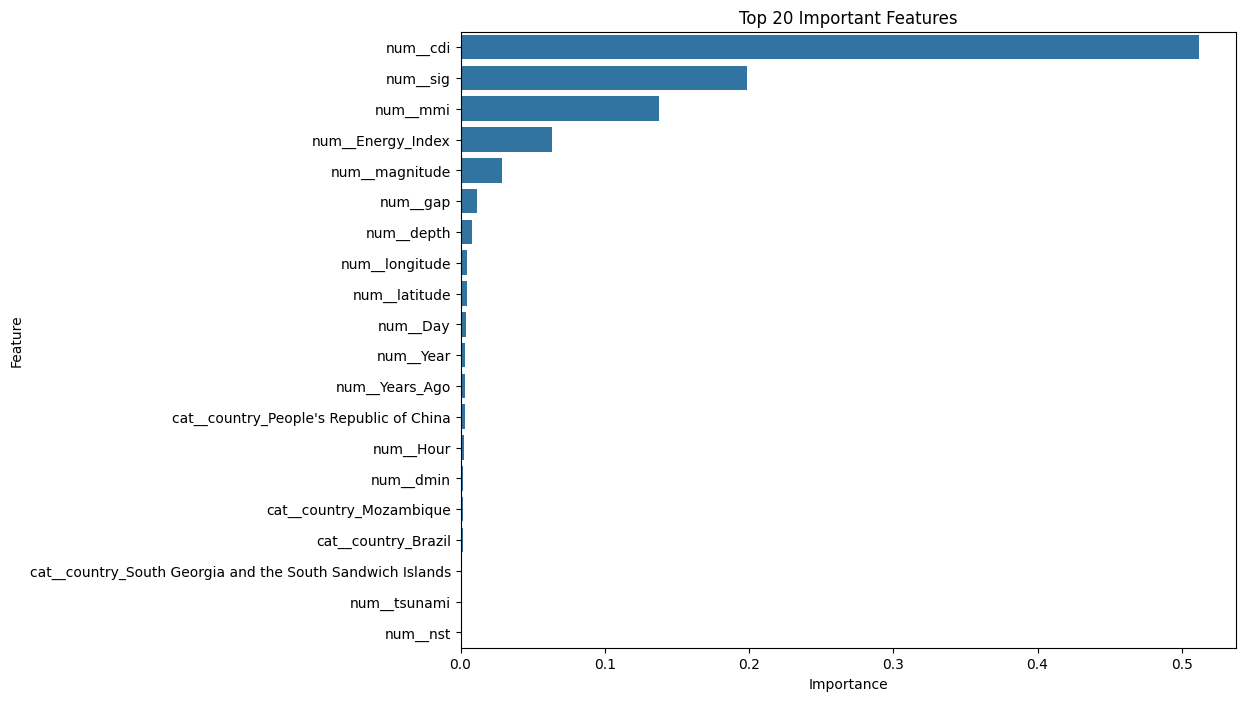

In [122]:
if importances is not None:

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=feature_df.head(20),

        x="Importance",

        y="Feature"

    )

    plt.title("Top 20 Important Features")

    plt.show()

In [125]:
results.to_csv(

"model_results.csv",

index=False

)

In [126]:
print("""

Model Building Completed Successfully

✔ Logistic Regression

✔ Decision Tree

✔ Random Forest

✔ KNN

✔ SVM

✔ Naive Bayes

✔ Gradient Boosting

✔ AdaBoost

✔ Extra Trees

✔ Best Model Saved

✔ Confusion Matrix

✔ Classification Report

✔ Feature Importance

✔ Results Saved

""")



Model Building Completed Successfully

✔ Logistic Regression

✔ Decision Tree

✔ Random Forest

✔ KNN

✔ SVM

✔ Naive Bayes

✔ Gradient Boosting

✔ AdaBoost

✔ Extra Trees

✔ Best Model Saved

✔ Confusion Matrix

✔ Classification Report

✔ Feature Importance

✔ Results Saved


